In [66]:
# General imports
import pandas as pd
import numpy as np
import itertools
import math
from tqdm import tqdm

# Import custom LIF SNN implementation
from LIF_SNN_network import SNNLayer

# Set random seed for reproducability
#np.random.seed(42)

**Test data**

In [67]:
df_train = pd.read_csv("CSV_results/train_spike_trains.csv")
df_test = pd.read_csv("CSV_results/test_spike_trains.csv")

spike_cols = [c for c in df_train.columns if c.startswith("spike_")]

input_spikes      = [list(map(int, row)) for row in df_train[spike_cols].values]
correct_outputs   = df_train["label"].tolist()

test_dataset         = [list(map(int, row)) for row in df_test[spike_cols].values]
test_correct_outputs = df_test["label"].tolist()

**Parameters**

In [68]:
# Input/Output size — derived from the loaded CSV (see data cell above)
# Best preprocessing config: 8×3 grid + 4 dist bits + 5 aruco bins = 33
n_inputs  = len(spike_cols)   # 33
n_outputs = 3

# Aruco position within the spike vector: grid + dist → aruco at end
# 8*3=24 grid bins + 4 dist bits = 28 → aruco at indices 28..32
aruco_start = n_inputs - 5    # = 28
n_aruco     = 5

# Training params
n_epochs = 15
n_runs = 5

# Neuron hyperparameters
decay_range = [128]
threshold_range = [1024]
reset_range = [0]

# Synapse parameters
lr_shift_range = [3]
initial_weight_range = [None]
t_pre_range = [3]
t_post_range = [2]
tau_e_shift_range = [3]
dw_pos_range = [32]
dw_neg_range = [32]
min_weight_range = [32]
max_weight_range = [127, 255, 99999]

# Dopamine: signed integer. Positive = reward, negative = punishment.
# delta_w = (eligibility * dopamine) >> lr_shift
dopamine_reward_range = [1, 4]   # reward magnitude
dopamine_punish_range = [-1, -2]  # punishment magnitude (negative)

mode_range = ['rstdp', 'stdp']

In [69]:
# Calculate total combinations and set up all configurations
ranges = [
    decay_range, threshold_range, reset_range,
    lr_shift_range, initial_weight_range,
    t_pre_range, t_post_range, tau_e_shift_range,
    dw_pos_range, dw_neg_range,
    min_weight_range, max_weight_range,
    dopamine_reward_range, dopamine_punish_range,
    mode_range
]

# Printing the total number of configurations
total_configurations = math.prod(map(len, ranges))
print(f"Number of configurations: ", total_configurations)

Number of configurations:  24


**Logging network activity**

In [70]:
# Initialize history lists
tuning_results = []
mean_run_acc = []
epoch_acc = []
num_correct = 0

In [71]:
def parse_aruco_state(spike_row, aruco_start, n_aruco):
    aruco = spike_row[aruco_start : aruco_start + n_aruco]
    seen  = bool(any(aruco))
    if not seen:
        return False, 0
    b = int(np.argmax(aruco))
    c = n_aruco // 2
    return True, (0 if b == c else (-1 if b < c else +1))


def reward_signal(seen, pos, action_idx, dopamine_reward, dopamine_punish):
    """Returns signed dopamine integer. Zero = no-op."""
    if seen and (
        (pos == 0  and action_idx == 1) or
        (pos == -1 and action_idx == 0) or
        (pos == +1 and action_idx == 2)
    ):
        return dopamine_reward  # correct alignment action: reward

    if not seen and action_idx in (0, 2):
        return 1                # searching: weak reward

    return dopamine_punish      # everything else: punish

**Run hyperparameter tuning**

In [72]:
for config in tqdm(itertools.product(*ranges), total=total_configurations):
    (decay, threshold, reset,
     lr_shift, initial_weight,
     t_pre, t_post, tau_e_shift,
     dw_pos, dw_neg,
     min_weight, max_weight,
     dopamine_reward, dopamine_punish,
     mode) = config

    neuron_params = {"decay": decay, "threshold": threshold, "reset": reset}
    synapse_params = {"lr_shift": lr_shift, "w_init": initial_weight,
                      "t_pre": t_pre, "t_post": t_post, "tau_e_shift": tau_e_shift,
                      "dw_pos": dw_pos, "dw_neg": dw_neg,
                      "w_min": min_weight, "w_max": max_weight,
                      "mode": mode}

    all_run_accs = []
    all_runs_test_acc = []

    for r in range(n_runs):
        SNN = SNNLayer(n_inputs=n_inputs, n_outputs=n_outputs,
                       synapse_params=synapse_params, neuron_params=neuron_params)

        epoch_acc = []
        epoch_test_acc = []

        for n in range(n_epochs):
            SNN.reset_state()
            num_correct = 0

            # --- TRAINING ---
            for current_spikes, correct_output in zip(input_spikes, correct_outputs):
                output_spikes = SNN.forward(input_spikes=current_spikes)
                winner_idx = SNN.winner_takes_all(output_spikes=output_spikes)

                seen, pos = parse_aruco_state(current_spikes, aruco_start, n_aruco)
                dopamine  = reward_signal(seen, pos, winner_idx, dopamine_reward, dopamine_punish)
                if dopamine != 0:
                    SNN.apply_reward(dopamine=dopamine, winner_idx=winner_idx)

                if winner_idx == correct_output:
                    num_correct += 1

            epoch_acc.append(num_correct / len(input_spikes))

            # --- TESTING ---
            SNN.reset_state()
            num_test_correct = 0

            for current_spikes, correct_output in zip(test_dataset, test_correct_outputs):
                output_spikes = SNN.forward(input_spikes=current_spikes)
                winner_idx = SNN.winner_takes_all(output_spikes=output_spikes)

                if winner_idx == correct_output:
                    num_test_correct += 1

            epoch_test_acc.append(num_test_correct / len(test_dataset))

        all_run_accs.append(epoch_acc[-1])        # final epoch only
        all_runs_test_acc.append(epoch_test_acc[-1])  # final epoch only

    tuning_results.append(
        neuron_params | synapse_params | {
            "dopamine_reward": dopamine_reward,
            "dopamine_punish": dopamine_punish,
            "mean_train_acc": np.mean(all_run_accs),
            "std_train_acc": np.std(all_run_accs),
            "mean_test_acc": np.mean(all_runs_test_acc),
            "std_test_acc": np.std(all_runs_test_acc),
        }
    )

  0%|          | 0/24 [00:00<?, ?it/s]

100%|██████████| 24/24 [07:00<00:00, 17.54s/it]


In [73]:
df_tuning_results = pd.DataFrame(tuning_results)
df_tuning_results.to_csv("CSV_results/SNN_hyperparameter_Results.csv", index=False)

In [74]:
"""# Save weights (uint8, no scaling needed)
weights = SNN.get_weights()
with open("weights.mem", "w") as f:
    for w in weights.flatten():
        f.write(f"{int(w) & 0xFF:02X}\n")"""

'# Save weights (uint8, no scaling needed)\nweights = SNN.get_weights()\nwith open("weights.mem", "w") as f:\n    for w in weights.flatten():\n        f.write(f"{int(w) & 0xFF:02X}\n")'

Final weights (rows=output neurons, cols=inputs):
[[  228   235   182   245   183   220   242   161   204   228   204   255
     86   136   255   206   150   199   199   244   110   141   179   262
     32    51    32   104    32   116   130   181   153]
 [99999 99999 99999 99999 99999 99999 99999 99999 99999 99999 99999 99999
  99999 99999 99999 99999 99999 99999 99999 99999 99999 99999 99999 99999
     32    32    32  8957    32  8681  9027  7408  5393]
 [   93   132    72   169    74   132   183   175   197   129   172    94
    117   123   178   109   121   199   176   144    94    74   150   184
     37    37    37   111    55    65   138   164    84]]


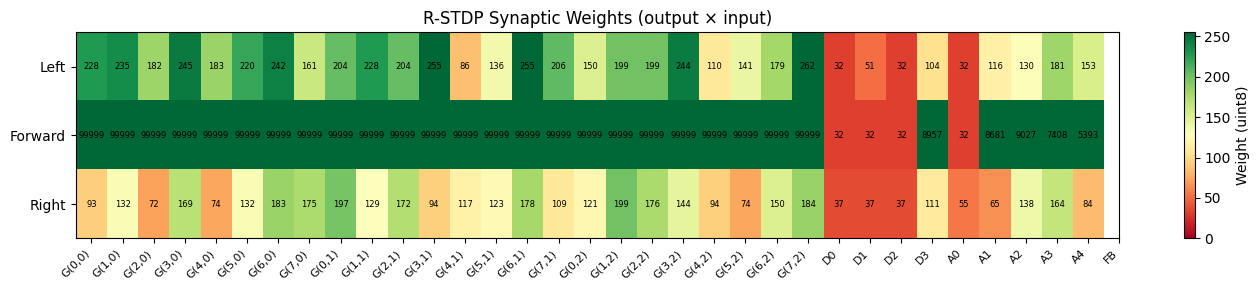

In [75]:
import matplotlib.pyplot as plt

weights = SNN.get_weights()  # shape: (3 output neurons, 34 inputs incl. feedback)
print("Final weights (rows=output neurons, cols=inputs):")
print(weights)

# Input labels for 34 inputs: 8×3 grid + 4 dist bits + 5 aruco bins + 1 feedback
input_labels = [
    # 8×3 occupancy grid (row-major: row 0 first)
    'G(0,0)', 'G(1,0)', 'G(2,0)', 'G(3,0)', 'G(4,0)', 'G(5,0)', 'G(6,0)', 'G(7,0)',  # row 0
    'G(0,1)', 'G(1,1)', 'G(2,1)', 'G(3,1)', 'G(4,1)', 'G(5,1)', 'G(6,1)', 'G(7,1)',  # row 1
    'G(0,2)', 'G(1,2)', 'G(2,2)', 'G(3,2)', 'G(4,2)', 'G(5,2)', 'G(6,2)', 'G(7,2)',  # row 2
    # 4-bit distance
    'D0', 'D1', 'D2', 'D3',
    # 5-bin aruco
    'A0', 'A1', 'A2', 'A3', 'A4',
    # feedback neuron (NOR of previous output spikes)
    'FB'
]
output_labels = ['Left', 'Forward', 'Right']

fig, ax = plt.subplots(figsize=(14, 3))
im = ax.imshow(weights, aspect='auto', cmap='RdYlGn', vmin=0, vmax=255)

ax.set_xticks(range(len(input_labels)))
ax.set_xticklabels(input_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(output_labels)))
ax.set_yticklabels(output_labels)
ax.set_title('R-STDP Synaptic Weights (output × input)')

# Annotate cells
for i in range(weights.shape[0]):
    for j in range(weights.shape[1]):
        ax.text(j, i, f'{weights[i,j]:.0f}', ha='center', va='center', fontsize=6)

plt.colorbar(im, ax=ax, label='Weight (uint8)')
plt.tight_layout()
plt.show()

**Output spike tracking**

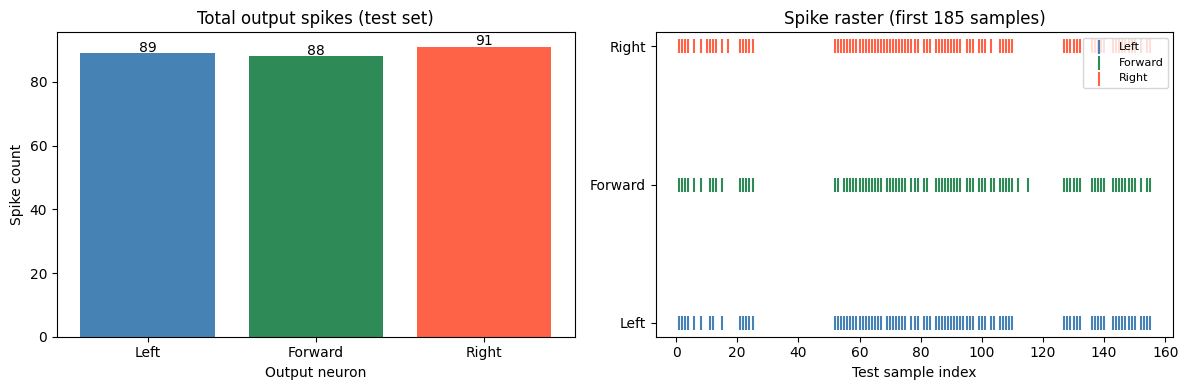

Spike rate per neuron:
      Left: 89/185 = 0.481
   Forward: 88/185 = 0.476
     Right: 91/185 = 0.492


In [76]:
import importlib
import LIF_SNN_network
importlib.reload(LIF_SNN_network)
from LIF_SNN_network import SNNLayer

# Re-run best config for spike tracking on test set
# Derive params from the tuning results computed above
_best = df_tuning_results.sort_values('mean_test_acc', ascending=False).iloc[0]
best_dopamine_reward = int(_best['dopamine_reward'])
best_dopamine_punish = int(_best['dopamine_punish'])
best_neuron_params  = {
    "decay":     int(_best['decay']),
    "threshold": int(_best['threshold']),
    "reset":     int(_best['reset']),
}
_w_init = None if pd.isna(_best['w_init']) else int(_best['w_init'])
best_synapse_params = {
    "lr_shift":    int(_best['lr_shift']),
    "w_init":      _w_init,
    "t_pre":       int(_best['t_pre']),
    "t_post":      int(_best['t_post']),
    "tau_e_shift": int(_best['tau_e_shift']),
    "dw_pos":      int(_best['dw_pos']),
    "dw_neg":      int(_best['dw_neg']),
    "w_min":       int(_best['w_min']),
    "w_max":       int(_best['w_max']),
    "mode":        str(_best['mode']),
}

np.random.seed(42)
snn_track = SNNLayer(n_inputs=n_inputs, n_outputs=n_outputs,
                     synapse_params=best_synapse_params,
                     neuron_params=best_neuron_params,
                     feedback=False)

# Train for 10 epochs (matches tuning loop)
for _ in range(n_epochs):
    snn_track.reset_state()
    for current_spikes, correct_output in zip(input_spikes, correct_outputs):
        output_spikes = snn_track.forward(input_spikes=current_spikes)
        winner_idx    = snn_track.winner_takes_all(output_spikes=output_spikes)
        seen, pos = parse_aruco_state(current_spikes, aruco_start, n_aruco)
        dopamine  = reward_signal(seen, pos, winner_idx, best_dopamine_reward, best_dopamine_punish)
        if dopamine != 0:
            snn_track.apply_reward(dopamine=dopamine, winner_idx=winner_idx)

# --- Test pass: collect per-timestep spikes ---
snn_track.reset_state()
output_labels = ['Left', 'Forward', 'Right']
spike_raster  = []

for current_spikes in test_dataset:
    out = snn_track.forward(input_spikes=current_spikes)
    spike_raster.append(out)

spike_raster = np.array(spike_raster)   # (n_samples, n_outputs)

# --- Plot 1: total spike counts per output neuron ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = snn_track.spike_count
axes[0].bar(output_labels, counts, color=['steelblue', 'seagreen', 'tomato'])
axes[0].set_title('Total output spikes (test set)')
axes[0].set_ylabel('Spike count')
axes[0].set_xlabel('Output neuron')
for i, v in enumerate(counts):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=10)

# --- Plot 2: spike raster (first 200 samples for readability) ---
n_show = min(200, len(spike_raster))
raster_slice = spike_raster[:n_show]

for neuron_idx in range(n_outputs):
    timesteps = np.where(raster_slice[:, neuron_idx] == 1)[0]
    axes[1].scatter(timesteps, np.full_like(timesteps, neuron_idx),
                    marker='|', s=100, linewidths=1.5,
                    color=['steelblue', 'seagreen', 'tomato'][neuron_idx],
                    label=output_labels[neuron_idx])

axes[1].set_yticks(range(n_outputs))
axes[1].set_yticklabels(output_labels)
axes[1].set_xlabel('Test sample index')
axes[1].set_title(f'Spike raster (first {n_show} samples)')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# Spike rate per neuron
print("Spike rate per neuron:")
for label, count in zip(output_labels, counts):
    print(f"  {label:>8}: {count}/{len(test_dataset)} = {count/len(test_dataset):.3f}")

**Eligibility trace tracking**

Eligibility history shape: (185, 3, 33)  (timesteps × outputs × inputs)


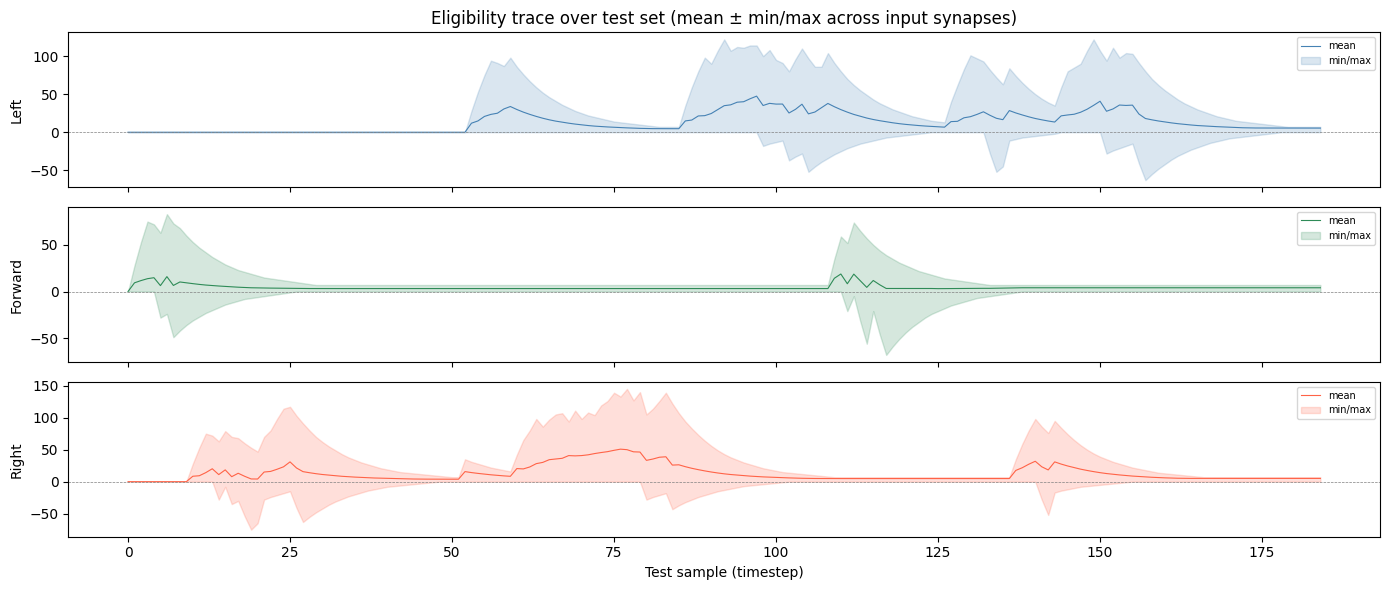

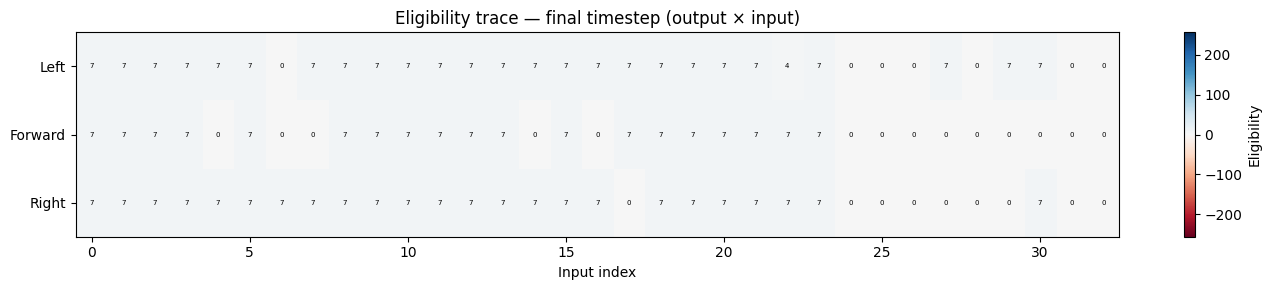

In [77]:
# Re-run best config with eligibility tracking enabled (test pass only)
np.random.seed(42)
snn_elig = SNNLayer(n_inputs=n_inputs, n_outputs=n_outputs,
                    synapse_params=best_synapse_params,
                    neuron_params=best_neuron_params,
                    feedback=False,
                    track_eligibility=True)

# Train without recording history to save memory
snn_elig.track_eligibility = False
for _ in range(n_epochs):
    snn_elig.reset_state()
    for current_spikes, correct_output in zip(input_spikes, correct_outputs):
        output_spikes = snn_elig.forward(input_spikes=current_spikes)
        winner_idx    = snn_elig.winner_takes_all(output_spikes=output_spikes)
        seen, pos = parse_aruco_state(current_spikes, aruco_start, n_aruco)
        dopamine  = reward_signal(seen, pos, winner_idx, best_dopamine_reward, best_dopamine_punish)
        if dopamine != 0:
            snn_elig.apply_reward(dopamine=dopamine, winner_idx=winner_idx)

# Enable tracking for test pass only
snn_elig.track_eligibility = True
snn_elig.reset_state()
for current_spikes in test_dataset:
    snn_elig.forward(input_spikes=current_spikes)

elig_hist = snn_elig.get_eligibility_history()  # (timesteps, n_outputs, n_inputs)
print(f"Eligibility history shape: {elig_hist.shape}  (timesteps × outputs × inputs)")

# --- Plot 1: eligibility over time for each output neuron (mean across inputs) ---
fig, axes = plt.subplots(n_outputs, 1, figsize=(14, 6), sharex=True)
colors = ['steelblue', 'seagreen', 'tomato']
for i, (ax, label, color) in enumerate(zip(axes, output_labels, colors)):
    ax.plot(elig_hist[:, i, :].mean(axis=1), color=color, linewidth=0.8, label='mean')
    ax.fill_between(range(len(elig_hist)),
                    elig_hist[:, i, :].min(axis=1),
                    elig_hist[:, i, :].max(axis=1),
                    alpha=0.2, color=color, label='min/max')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_ylabel(label)
    ax.legend(loc='upper right', fontsize=7)
axes[-1].set_xlabel('Test sample (timestep)')
axes[0].set_title('Eligibility trace over test set (mean ± min/max across input synapses)')
plt.tight_layout()
plt.show()

# --- Plot 2: heatmap of final eligibility state (n_outputs × n_inputs) ---
final_elig = elig_hist[-1]   # last timestep

fig, ax = plt.subplots(figsize=(14, 3))
im = ax.imshow(final_elig, aspect='auto', cmap='RdBu', vmin=-256, vmax=256)
ax.set_yticks(range(n_outputs))
ax.set_yticklabels(output_labels)
ax.set_xlabel('Input index')
ax.set_title('Eligibility trace — final timestep (output × input)')
for i in range(final_elig.shape[0]):
    for j in range(final_elig.shape[1]):
        ax.text(j, i, str(final_elig[i, j]), ha='center', va='center', fontsize=5)
plt.colorbar(im, ax=ax, label='Eligibility')
plt.tight_layout()
plt.show()

In [78]:
# Load grid search results
df = pd.read_csv("CSV_results/SNN_hyperparameter_Results.csv")

# Top 25 configurations
top_25 = df.sort_values(by=['mean_test_acc'], ascending=[False]).head(25)

print("=== Top 25 SNN Configurations ===")
print(top_25[['mean_test_acc', 'decay', 'threshold', 'w_init', 'reset', 'lr_shift', 'mode',
              't_pre', 't_post', 'tau_e_shift', 'dw_pos', 'dw_neg',
              'w_min', 'w_max', 'dopamine_reward', 'dopamine_punish']])

# Parameter impact analysis
print("\n=== Impact of Decay on Accuracy ===")
print(df.groupby('decay')['mean_test_acc'].mean())

print("\n=== Impact of Threshold on Accuracy ===")
print(df.groupby('threshold')['mean_test_acc'].mean())

print("\n=== Impact of lr_shift on Accuracy ===")
print(df.groupby('lr_shift')['mean_test_acc'].mean())

print("\n=== Impact of dw_pos on Accuracy ===")
print(df.groupby('dw_pos')['mean_test_acc'].mean())

print("\n=== Impact of dw_neg on Accuracy ===")
print(df.groupby('dw_neg')['mean_test_acc'].mean())

print("\n=== Impact of tau_e_shift on Accuracy ===")
print(df.groupby('tau_e_shift')['mean_test_acc'].mean())

print("\n=== Impact of w_init on Accuracy ===")
print(df.groupby('w_init')['mean_test_acc'].mean())

print("\n=== Impact of dopamine_reward on Accuracy ===")
print(df.groupby('dopamine_reward')['mean_test_acc'].mean())

print("\n=== Impact of dopamine_punish on Accuracy ===")
print(df.groupby('dopamine_punish')['mean_test_acc'].mean())

# Best overall
print("\n=== Best Overall Config ===")
best = df.sort_values('mean_test_acc', ascending=False).iloc[0]
print(best)

# Worst overall
print("\n=== Worst Overall Config ===")
worst = df.sort_values('mean_test_acc', ascending=True).iloc[0]
print(worst)

=== Top 25 SNN Configurations ===
    mean_test_acc  decay  threshold  w_init  reset  lr_shift   mode  t_pre  \
7        0.409730    128       1024     NaN      0         3   stdp      3   
2        0.391351    128       1024     NaN      0         3  rstdp      3   
9        0.381622    128       1024     NaN      0         3   stdp      3   
19       0.371892    128       1024     NaN      0         3   stdp      3   
10       0.340541    128       1024     NaN      0         3  rstdp      3   
23       0.332973    128       1024     NaN      0         3   stdp      3   
3        0.331892    128       1024     NaN      0         3   stdp      3   
15       0.331892    128       1024     NaN      0         3   stdp      3   
4        0.320000    128       1024     NaN      0         3  rstdp      3   
11       0.318919    128       1024     NaN      0         3   stdp      3   
0        0.318919    128       1024     NaN      0         3  rstdp      3   
1        0.315676    128      